# Parcing Dates (Analizando fechas)

En Python, es posible hacer de las fechas un tipo de dato. Esto sirve de mucha ayuda cuando ya tenemos un formato de fecha definido y lo queremos cambiar a otro, pasa muchas veces cuando queremos tomar un dataset de ingles a español, en donde el formato es mes-dia-año a dia-mes-año. Suele pasar que los conjuntos de datos tienen fechas con una mal formato o incorrecto segun la forma en la que se declaro, asi que es necesario arreglarlo.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import datetime

landslides = pd.read_csv("data/catalog.csv")
np.random.seed(0)

In [2]:
landslides.head()

,id,date,time,continent_code,country_name,country_code,state/province,population,city/town,distance,...,geolocation,hazard_type,landslide_type,landslide_size,trigger,storm_name,injuries,fatalities,source_name,source_link
0,34,3/2/07,Night,NaN,United States,US,Virginia,16000,Cherry Hill,3.40765,...,"(38.600900000000003, -77.268199999999993)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,NBC 4 news,http://www.nbc4.com/news/11186871/detail.html
1,42,3/22/07,NaN,NaN,United States,US,Ohio,17288,New Philadelphia,3.33522,...,"(40.517499999999998, -81.430499999999995)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,Canton Rep.com,http://www.cantonrep.com/index.php?ID=345054&C...
2,56,4/6/07,NaN,NaN,United States,US,Pennsylvania,15930,Wilkinsburg,2.91977,...,"(40.4377, -79.915999999999997)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,The Pittsburgh Channel.com,https://web.archive.org/web/20080423132842/htt...
3,59,4/14/07,NaN,NaN,Canada,CA,Quebec,42786,Châteauguay,2.98682,...,"(45.322600000000001, -73.777100000000004)",Landslide,Riverbank collapse,Small,Rain,NaN,NaN,NaN,Le Soleil,http://www.hebdos.net/lsc/edition162007/articl...
4,61,4/15/07,NaN,NaN,United States,US,Kentucky,6903,Pikeville,5.66542,...,"(37.432499999999997, -82.493099999999998)",Landslide,Landslide,Small,Downpour,NaN,NaN,0.0,Matthew Crawford (KGS),NaN


Comenzamos a ver que el formato de la fecha es m/d/a. Ahora, veamoslo mas de cerca.

In [3]:
print(landslides['date'].head())

0     3/2/07
1    3/22/07
2     4/6/07
3    4/14/07
4    4/15/07
Name: date, dtype: object


Como habiamos dicho, estos son datos, pero para la computadora solo es un string mas. Hay que hacerle saber que las fechas son un dato importante y no hay mejor opcion que hacerlo un tipo de dato propio.

In [4]:
landslides['date'].dtype

dtype('O')

Vemos que el tipo de dato de `date` es una **O** de objeto, convirtamosla a dato. Pero antes de hacerlo, definamos su formato.

In [8]:
landslides['date_parsed'] = pd.to_datetime(landslides['date'], format = "%m/%d/%y")

# checamos que sea correcto el formato

landslides['date_parsed'].head()

0   2007-03-02
1   2007-03-22
2   2007-04-06
3   2007-04-14
4   2007-04-15
Name: date_parsed, dtype: datetime64[ns]

## Selecciona el dia del mes
Si queremos seleccionar el dia de los registros. Entonces ocupamos lo siguiente.

In [9]:
day_of_month_landslides = landslides['date_parsed'].dt.day
day_of_month_landslides.head()

0     2.0
1    22.0
2     6.0
3    14.0
4    15.0
Name: date_parsed, dtype: float64

## Grafiquemos

C:\Users\CDWLu\AppData\Local\Temp\ipykernel_5184\910547780.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(day_of_month_landslides, kde = False, bins = 31)


<Axes: xlabel='date_parsed'>

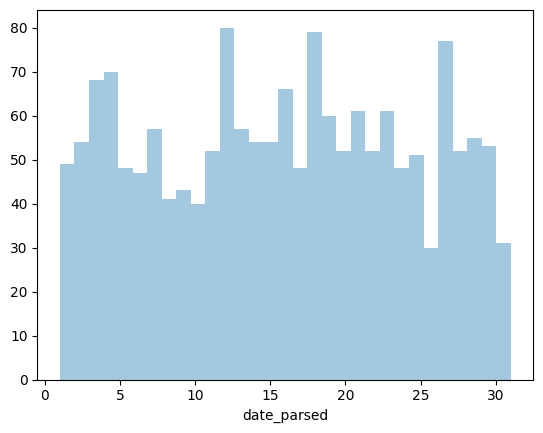

In [12]:
day_of_month_landslides = day_of_month_landslides.dropna()

sns.distplot(day_of_month_landslides, kde = False, bins = 31)